In [100]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import matplotlib.tri as tri
import numpy as np 
import math
from scipy.special import kv 
from scipy.special import kve
from scipy import integrate
from joblib import Parallel, delayed
from scipy.integrate import quad
from numba import njit, prange
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
from scipy.integrate import dblquad
from scipy.interpolate import CubicSpline

In [101]:
DTT = open('MV Dipole table.txt','r')
with open("MV Dipole table.txt", "r") as file:
    lines = file.readlines()
print(lines)

['     Y            r             N(r,Y) \n', '0.0000000000000000 0.0000010000000000 0.0000000000003962\n', '0.0000000000000000 0.0000010472494123 0.0000000000004332\n', '0.0000000000000000 0.0000010967313316 0.0000000000004737\n', '0.0000000000000000 0.0000011485512424 0.0000000000005179\n', '0.0000000000000000 0.0000012028196136 0.0000000000005663\n', '0.0000000000000000 0.0000012596521335 0.0000000000006191\n', '0.0000000000000000 0.0000013191699565 0.0000000000006769\n', '0.0000000000000000 0.0000013814999616 0.0000000000007401\n', '0.0000000000000000 0.0000014467750229 0.0000000000008092\n', '0.0000000000000000 0.0000015151342925 0.0000000000008847\n', '0.0000000000000000 0.0000015867234973 0.0000000000009673\n', '0.0000000000000000 0.0000016616952501 0.0000000000010575\n', '0.0000000000000000 0.0000017402093741 0.0000000000011562\n', '0.0000000000000000 0.0000018224332443 0.0000000000012641\n', '0.0000000000000000 0.0000019085421440 0.0000000000013820\n', '0.0000000000000000 0.00

In [102]:
MVA = open('redx-2009-parsed-small-x(2).txt','r')
with open("redx-2009-parsed-small-x(2).txt", "r") as file:
    linesR = file.readlines()
print(linesR)

['roots [GeV]    Q2 [GeV2]                  x                  sigma_r         relative error sigma_r \n', '301.0000000000000000 0.0450000000000000 0.0000006210000000       0.0800000000000000             9.7674715254256057 \n', '301.0000000000000000 0.0650000000000000 0.0000008970000000       0.1110000000000000             8.0017748031296154 \n', '301.0000000000000000 0.0650000000000000 0.0000010200000000       0.1110000000000000             8.7284935699122794 \n', '301.0000000000000000 0.0850000000000000 0.0000011700000000       0.1360000000000000             7.3905547829645375 \n', '301.0000000000000000 0.0850000000000000 0.0000013400000000       0.1300000000000000             5.4943516450988099 \n', '301.0000000000000000 0.0850000000000000 0.0000015600000000       0.1260000000000000             6.8720375435528576 \n', '301.0000000000000000 0.1000000000000000 0.0000015100000000       0.1650000000000000             7.8332560279873400 \n', '301.0000000000000000 0.1000000000000000 0.000

In [103]:
DIPOLEdata = np.loadtxt('MV Dipole table.txt', skiprows=1)

# Split into separate arrays
Y = DIPOLEdata[:, 0]
R = DIPOLEdata[:, 1]
N = DIPOLEdata[:, 2]

In [104]:
# Build Y_vals, R_vals_dip, N_grid as before
Y_vals = np.unique(Y)
R_vals_dip = np.unique(R)
# Build the 2D dipole amplitude grid N(Y, R)
NY = len(Y_vals)
NR = len(R_vals_dip)

N_grid = np.zeros((NY, NR))

for i in range(len(N)):
    iy = np.searchsorted(Y_vals, Y[i])
    ir = np.searchsorted(R_vals_dip, R[i])
    N_grid[iy, ir] = N[i]


# Convert Y -> x
x_vals = 0.01 * np.exp(-Y_vals)

# IMPORTANT: ensure x is increasing for searchsorted
if x_vals[0] > x_vals[-1]:
    x_vals = x_vals[::-1]
    N_grid = N_grid[::-1, :]

# Make contiguous (Numba requirement)
x_vals = np.ascontiguousarray(x_vals, dtype=np.float64)
R_vals_dip = np.ascontiguousarray(R_vals_dip, dtype=np.float64)
N_grid = np.ascontiguousarray(N_grid, dtype=np.float64)

In [105]:
#-----------------Linear Interpolation-----------------------------
@njit(fastmath=True)
def dipole_amplitude_x(x, R, x_vals, R_vals, N_grid):

    # --- x index ---
    if x <= x_vals[0]:
        ix = 0
    elif x >= x_vals[-1]:
        ix = len(x_vals) - 2
    else:
        ix = np.searchsorted(x_vals, x) - 1

    # --- R index ---
    if R <= R_vals[0]:
        ir = 0
    elif R >= R_vals[-1]:
       ir = len(R_vals) - 2
    else:
        ir = np.searchsorted(R_vals, R) - 1

    x1 = x_vals[ix]
    x2 = x_vals[ix + 1]
    R1 = R_vals[ir]
    R2 = R_vals[ir + 1]

    # interpolation weights
    tx = (x - x1) / (x2 - x1)
    tR = (R - R1) / (R2 - R1)

    N11 = N_grid[ix,     ir]
    N12 = N_grid[ix,     ir + 1]
    N21 = N_grid[ix + 1, ir]
    N22 = N_grid[ix + 1, ir + 1]

    return ((1 - tx) * (1 - tR) * N11 +
            (1 - tx) * tR       * N12 +
            tx       * (1 - tR) * N21 +
            tx       * tR       * N22)

In [106]:
DISdata = np.loadtxt('redx-2009-parsed-small-x(2).txt', skiprows=1)

# Split into separate arrays
roots_DIS = DISdata[:,0]
s_DIS = roots_DIS**2
Q2_DIS= DISdata[:, 1]
x_DIS = DISdata[:, 2]
sigma_r_DIS = DISdata[:, 3]
rel_err_sigma_r_DIS = DISdata[:, 4]

lengthQ2_DIS = len(Q2_DIS)
lengthx_DIS = len(x_DIS)

In [107]:
Q2sO = 0.104
PiRp2MV = 18.81 * 2.56819 
ef2 = (2/3)**2 + (-1/3)**2 + (-1/3)**2
mf = 0.140
Alpha_em = 1 / 137
e = math.e 
nc = 3

In [108]:
def y(x_vals, Q2_vals, s_val): 
    return (Q2_vals)/(x_vals * s_val)

In [113]:
# ---------------------------------------------------------------------
# --- Precompute Bessel functions (SciPy) for a given Q² --------------
# ---------------------------------------------------------------------
def precompute_bessel(Q2_val, nZ=1300, nR=1300):
    """Precompute K0 and K1 safely using scaled Bessel functions."""
    z_vals = np.linspace(0, 1, nZ)
    #R_vals = np.linspace(1e-6, 10 / np.sqrt(Q2_val), nR)
    R_vals = np.linspace(1e-6, 100, nR)
    K0 = np.zeros((nZ, nR))
    K1 = np.zeros((nZ, nR))
    for i, z in enumerate(z_vals):
        arg = np.sqrt(z * (1 - z) * Q2_val + mf**2) * R_vals
        #Scaled Bessel to avoid underflow
        K0[i, :] = kve(0, arg) * np.exp(-arg)
        K1[i, :] = kve(1, arg) * np.exp(-arg)
    return z_vals, R_vals, K0, K1

In [114]:
# ---------------------------------------------------------------------
# --- Numba accelerated integrator MV --------------------------------
# ---------------------------------------------------------------------
@njit(parallel=True, fastmath=True)
def SigmaLDP_numba(x_val, Q2_val, z_vals, R_vals, K0_grid, x_vals, R_vals_dip, N_grid):
    total = 0.0
    dz = z_vals[1] - z_vals[0]
    dR = R_vals[1] - R_vals[0]

    for i in prange(len(z_vals)):
        z = z_vals[i]
        #for j in range(len(R_vals)):
            #R = R_vals[j]
        for j in range(len(R_vals)-1):

            R = R_vals[j]

            dR = R_vals[j+1] - R_vals[j]
            
            K0v = K0_grid[i, j]
            psiL = ((2 * nc * Alpha_em * ef2) / (math.pi**2)
                    * z**2 * (1 - z)**2 * Q2_val * K0v**2)
            
            #-----------Test N----------------
            Nval = dipole_amplitude_x(
                x_val, R,
                x_vals, R_vals_dip, N_grid)
            

            total += 4 * math.pi * PiRp2MV * R * psiL * Nval * dR * dz

    return total

In [115]:
# --- same for T component --------------------------------------------
@njit(parallel=True, fastmath=True)
def SigmaTDP_numba(x_val, Q2_val, z_vals, R_vals, K0_grid, K1_grid, x_vals, R_vals_dip, N_grid):
    total = 0.0
    dz = z_vals[1] - z_vals[0]
    dR = R_vals[1] - R_vals[0]

    for i in prange(len(z_vals)):
        z = z_vals[i]
        Qz = math.sqrt(z * (1 - z) * Q2_val + mf**2)
        #for j in range(len(R_vals)):
            #R = R_vals[j]
        for j in range(len(R_vals)-1):

            R = R_vals[j]

            dR = R_vals[j+1] - R_vals[j]
            
            K0v = K0_grid[i, j]
            K1v = K1_grid[i, j]

            psiT = ((nc * Alpha_em * ef2) / (2 * math.pi**2)
                    * ((z**2 + (1 - z)**2) * Qz**2 * K1v**2
                       + mf**2 * K0v**2))

              # dipole amplitude from table
            #-----------Test N----------------
            Nval = dipole_amplitude_x(
                x_val, R,
                x_vals, R_vals_dip, N_grid)
            

            total += 4 * math.pi * PiRp2MV * R * psiT * Nval * dR * dz

    return total

In [116]:
def FLDP(x_val, Q2_val, z_vals, R_vals, K0_grid, x_vals, R_vals_dip, N_grid):
    return (Q2_val / (4 * math.pi**2 * Alpha_em)) * SigmaLDP_numba(x_val, Q2_val, z_vals, R_vals, K0_grid, x_vals, R_vals_dip, N_grid)

def F2DP(x_val, Q2_val, z_vals, R_vals, K0_grid, K1_grid, x_vals, R_vals_dip, N_grid):
    sigL = SigmaLDP_numba(x_val, Q2_val, z_vals, R_vals, K0_grid, x_vals, R_vals_dip, N_grid)
    sigT = SigmaTDP_numba(x_val, Q2_val, z_vals, R_vals, K0_grid, K1_grid, x_vals, R_vals_dip, N_grid)
    return (Q2_val / (4 * math.pi**2 * Alpha_em)) * (sigL + sigT)

def FLF2DP(x_val, Q2_val, z_vals, R_vals, K0_grid, K1_grid, x_vals, R_vals_dip, N_grid):
    FL = FLDP(x_val, Q2_val, z_vals, R_vals, K0_grid, x_vals, R_vals_dip, N_grid)
    F2 = F2DP(x_val, Q2_val, z_vals, R_vals, K0_grid, K1_grid, x_vals, R_vals_dip, N_grid)
    return FL / F2

def SigmaRDP(x_val, Q2_val, s_val, z_vals, R_vals, K0_grid, K1_grid, x_vals, R_vals_dip, N_grid):
    y_val = y(x_val, Q2_val, s_val)
    return (
        Q2_val / (4 * np.pi**2 * Alpha_em)
        * (
            SigmaTDP_numba(x_val, Q2_val, z_vals, R_vals, K0_grid, K1_grid,
                           x_vals, R_vals_dip, N_grid)
            +
            (2 * (1 - y_val)) / (1 + (1 - y_val)**2)
            * SigmaLDP_numba(x_val, Q2_val, z_vals, R_vals, K0_grid,
                             x_vals, R_vals_dip, N_grid)
        )
    )


In [117]:
# ---------------------------------------------------------------------
# --- Old Data Grids For physical data ----------------------------
# ---------------------------------------------------------------------

def compute_FL_grid():
    FL_data = np.zeros((len(Q2_DIS), len(x_DIS)))
    for i, Q2_val in enumerate(Q2_DIS):
        #print(f"Precomputing Bessel functions for Q² = {Q2:.3e}")
        z_vals, R_vals, K0_grid, K1_grid = precompute_bessel(Q2_val)
        results = Parallel(n_jobs=-1)(
            delayed(FLDP)(x_val, Q2_val, z_vals, R_vals, K0_grid, x_vals, R_vals_dip, N_grid) for x_val in x_DIS
        )
        FL_data[i, :] = results
    return FL_data

FLDPData = compute_FL_grid()

def compute_F2_grid():
    F2_data = np.zeros((len(Q2_DIS), len(x_DIS)))
    for i, Q2_val in enumerate(Q2_DIS):
        #print(f"Precomputing Bessel functions for Q² = {Q2:.3e}")
        z_vals, R_vals, K0_grid, K1_grid = precompute_bessel(Q2_val)
        results = Parallel(n_jobs=-1)(
            delayed(F2DP)(x_val, Q2_val, z_vals, R_vals, K0_grid, K1_grid, x_vals, R_vals_dip, N_grid) for x_val in x_DIS
        )
        F2_data[i, :] = results
    return F2_data

F2DPData = compute_F2_grid()

def compute_FLF2_grid():
    FLF2_data = np.zeros((len(Q2_DIS), len(x_DIS)))
    for i, Q2_val in enumerate(Q2_DIS):
        #print(f"Precomputing Bessel functions for Q² = {Q2:.3e}")
        z_vals, R_vals, K0_grid, K1_grid = precompute_bessel(Q2_val)
        results = Parallel(n_jobs=-1)(
            delayed(FLF2DP)(x_val, Q2_val, z_vals, R_vals, K0_grid, K1_grid, x_vals, R_vals_dip, N_grid) for x_val in x_DIS
        )
        FLF2_data[i, :] = results
    return FLF2_data

FLF2DPData = compute_FLF2_grid()

def compute_SigmaR_grid():
    SigmaR_data = np.zeros((len(Q2_DIS), len(x_DIS)))
    for i, Q2_val in enumerate(Q2_DIS):
        #print(f"Precomputing Bessel functions for Q² = {Q2:.3e}")
        z_vals, R_vals, K0_grid, K1_grid = precompute_bessel(Q2_val)
        results = Parallel(n_jobs=-1)(
            delayed(SigmaRDP)(x_val, Q2_val, s_DIS[i], z_vals, R_vals, K0_grid, K1_grid, x_vals, R_vals_dip, N_grid) for x_val in x_DIS
        )
        SigmaR_data[i, :] = results
    return SigmaR_data

SigmaRDPData = compute_SigmaR_grid()

def compute_SigmaRDP_points():
    SigmaR_data = np.zeros(len(x_DIS))

    for i in range(len(x_DIS)):

        x_val  = x_DIS[i]
        Q2_val = Q2_DIS[i]
        s_val  = s_DIS[i]

        z_vals, R_vals, K0_grid, K1_grid = precompute_bessel(Q2_val)

        SigmaR_data[i] = SigmaRDP(
            x_val, Q2_val, s_val,
            z_vals, R_vals, K0_grid, K1_grid,
            x_vals, R_vals_dip, N_grid
        )

    return SigmaR_data

SigmaRDP_points = compute_SigmaRDP_points()

In [1]:
x_grid, Q2_grid = np.meshgrid(x_DIS, Q2_DIS)  

plt.figure(figsize=(8, 6))
contour = plt.contourf(x_grid, Q2_grid , FLDPData.T, levels=50, cmap='viridis')

# Set both axes to logarithmic scale
plt.xscale('log')
plt.yscale('log')


# Add labels and colorbar
plt.ylabel(r'$Q^2$ [GeV$^2$]')
plt.xlabel(r'$x$')
plt.title(r'Contour plot of $F_L^{DPDATA}(x, Q^2)$')
plt.colorbar(contour, label=r'$F_L^{DPDATA}$')

plt.tight_layout()
plt.show()

NameError: name 'np' is not defined

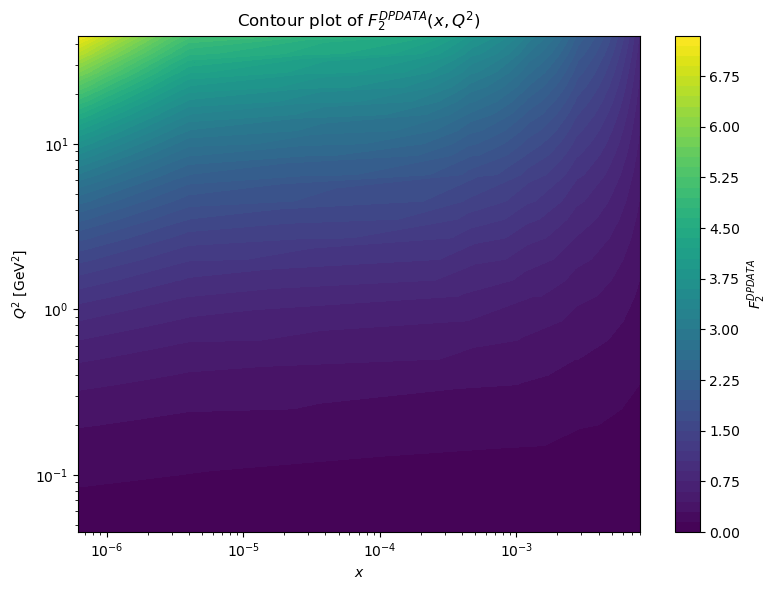

In [119]:
x_grid, Q2_grid  = np.meshgrid(Q2_DIS, x_DIS)  

plt.figure(figsize=(8, 6))
contour = plt.contourf(Q2_grid, x_grid , F2DPData.T, levels=50, cmap='viridis')

# Set both axes to logarithmic scale
plt.xscale('log')
plt.yscale('log')

# Add labels and colorbar
plt.ylabel(r'$Q^2$ [GeV$^2$]')
plt.xlabel(r'$x$')
plt.title(r'Contour plot of $F_2^{DPDATA}(x, Q^2)$')
plt.colorbar(contour, label=r'$F_2^{DPDATA}$')

plt.tight_layout()
plt.show()

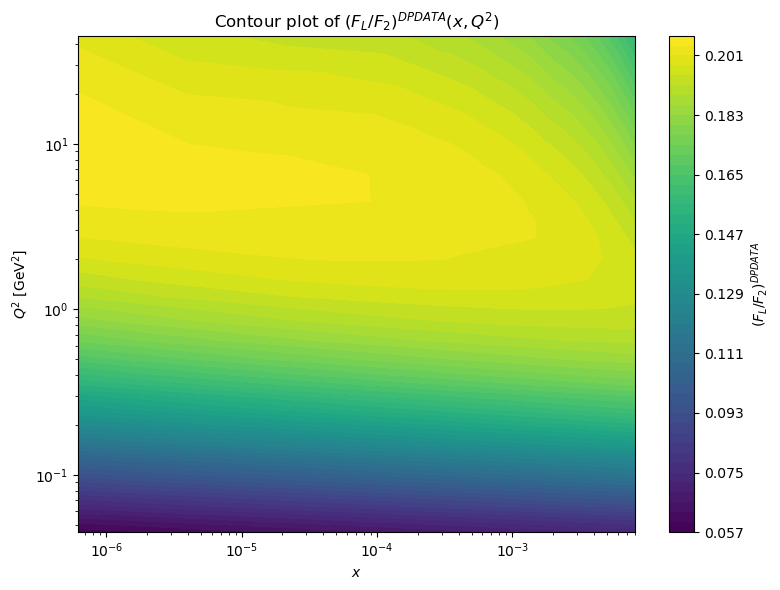

In [120]:
x_grid, Q2_grid = np.meshgrid(Q2_DIS, x_DIS)  

plt.figure(figsize=(8, 6))
contour = plt.contourf(Q2_grid, x_grid , FLF2DPData.T, levels=50, cmap='viridis')

# Set both axes to logarithmic scale
plt.xscale('log')
plt.yscale('log')

# Add labels and colorbar
plt.ylabel(r'$Q^2$ [GeV$^2$]')
plt.xlabel(r'$x$')
plt.title(r'Contour plot of $(F_L/F_2)^{DPDATA}(x, Q^2)$')
plt.colorbar(contour, label=r'$(F_L/F_2)^{DPDATA}$')

plt.tight_layout()
plt.show()

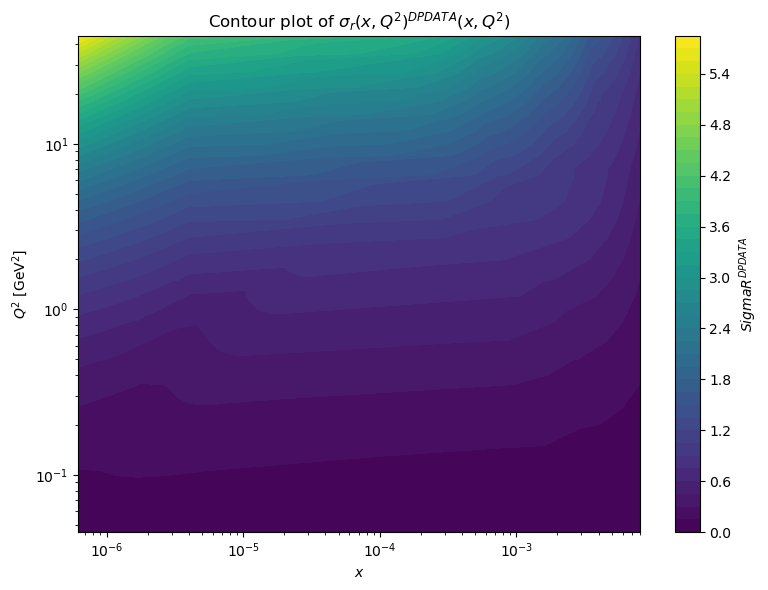

In [121]:
x_grid, Q2_grid = np.meshgrid(Q2_DIS, x_DIS) 

plt.figure(figsize=(8, 6))
contour = plt.contourf(Q2_grid, x_grid , SigmaRDPData.T, levels=50, cmap='viridis')

# Set both axes to logarithmic scale
plt.xscale('log')
plt.yscale('log')

# Add labels and colorbar
plt.ylabel(r'$Q^2$ [GeV$^2$]')
plt.xlabel(r'$x$')
plt.title(r'Contour plot of $\sigma_r(x, Q^2)^{DPDATA}(x, Q^2)$')
plt.colorbar(contour, label=r'$SigmaR^{DPDATA}$')

plt.tight_layout()
plt.show()

Using Q² = 8.5000 GeV²


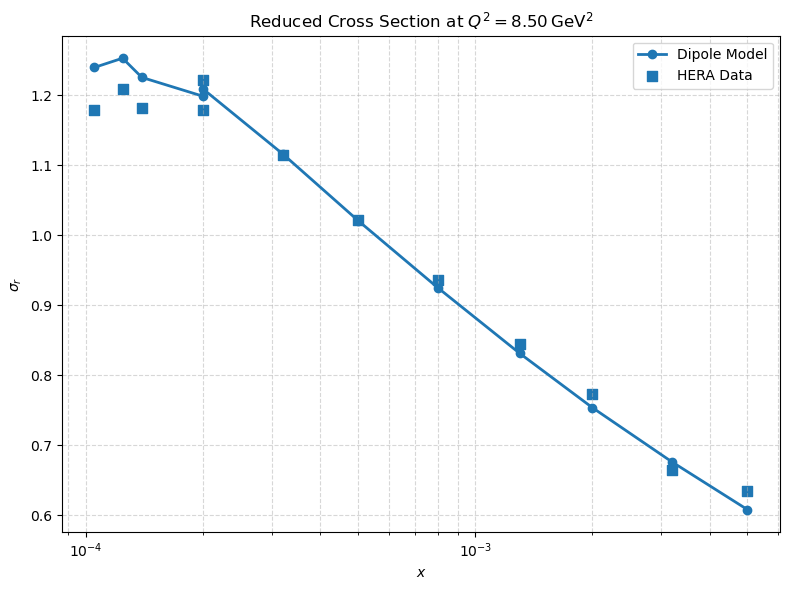

In [122]:
# ----------------------------------------------------------
# Fixed Q² Reduced Cross Section Plot
# Using physical HERA x-values only
# ----------------------------------------------------------

# Desired Q²
Q2_fixed = 8.5

# ----------------------------------------------------------
# Find nearest available experimental Q²
# ----------------------------------------------------------

Q2_unique = np.unique(Q2_DIS)

Q2_selected = Q2_unique[
    np.argmin(np.abs(Q2_unique - Q2_fixed))
]

print(f"Using Q² = {Q2_selected:.4f} GeV²")

# ----------------------------------------------------------
# Select only points with this Q²
# ----------------------------------------------------------

mask = Q2_DIS == Q2_selected

x_selected = x_DIS[mask]
s_selected = s_DIS[mask]

# Experimental reduced cross section
sigma_exp = sigma_r_DIS[mask]

# ----------------------------------------------------------
# Precompute Bessel functions ONCE
# ----------------------------------------------------------

z_vals, R_vals, K0_grid, K1_grid = precompute_bessel(Q2_selected)

# ----------------------------------------------------------
# Compute reduced cross section
# ----------------------------------------------------------

SigmaR_curve = np.zeros(len(x_selected))

for i in range(len(x_selected)):

    SigmaR_curve[i] = SigmaRDP(
        x_selected[i],          # x
        Q2_selected,            # fixed Q²
        s_selected[i],          # corresponding s
        z_vals,
        R_vals,
        K0_grid,
        K1_grid,
        x_vals,
        R_vals_dip,
        N_grid
    )

# ----------------------------------------------------------
# Sort for plotting
# ----------------------------------------------------------

sort_idx = np.argsort(x_selected)

x_plot = x_selected[sort_idx]
sigma_plot = SigmaR_curve[sort_idx]
sigma_exp_plot = sigma_exp[sort_idx]

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

plt.figure(figsize=(8,6))

# Theory curve
plt.plot(
    x_plot,
    sigma_plot,
    marker='o',
    linestyle='-',
    linewidth=2,
    label='Dipole Model'
)

# Experimental points
plt.scatter(
    x_plot,
    sigma_exp_plot,
    marker='s',
    s=60,
    label='HERA Data'
)

# Log x-axis
plt.xscale('log')

# Labels
plt.xlabel(r'$x$')
plt.ylabel(r'$\sigma_r$')

# Title
plt.title(
    rf'Reduced Cross Section at $Q^2={Q2_selected:.2f}\,\mathrm{{GeV}}^2$'
)

# Grid and legend
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

Using Q² = 1.5000 GeV²


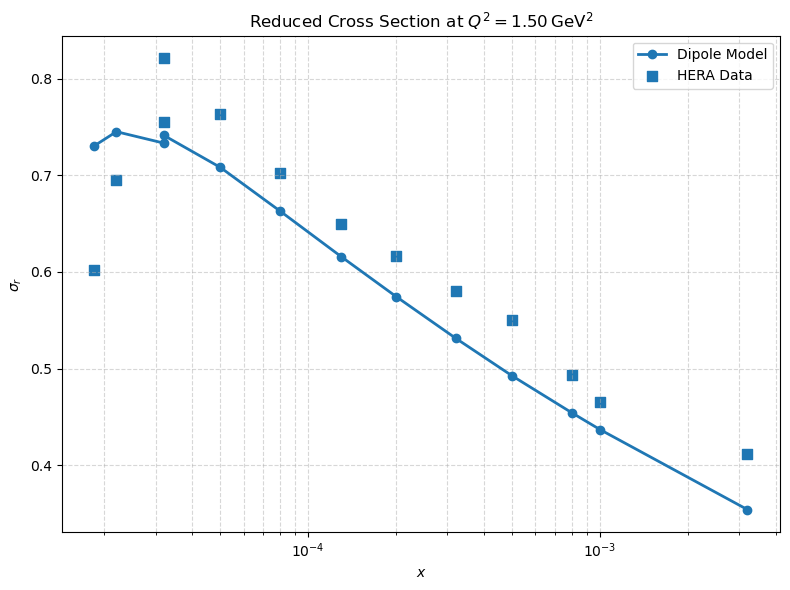

In [123]:
# ----------------------------------------------------------
# Fixed Q² Reduced Cross Section Plot
# Using physical HERA x-values only
# ----------------------------------------------------------

# Desired Q²
Q2_fixed = 1.5

# ----------------------------------------------------------
# Find nearest available experimental Q²
# ----------------------------------------------------------

Q2_unique = np.unique(Q2_DIS)

Q2_selected = Q2_unique[
    np.argmin(np.abs(Q2_unique - Q2_fixed))
]

print(f"Using Q² = {Q2_selected:.4f} GeV²")

# ----------------------------------------------------------
# Select only points with this Q²
# ----------------------------------------------------------

mask = Q2_DIS == Q2_selected

x_selected = x_DIS[mask]
s_selected = s_DIS[mask]

# Experimental reduced cross section
sigma_exp = sigma_r_DIS[mask]

# ----------------------------------------------------------
# Precompute Bessel functions ONCE
# ----------------------------------------------------------

z_vals, R_vals, K0_grid, K1_grid = precompute_bessel(Q2_selected)

# ----------------------------------------------------------
# Compute reduced cross section
# ----------------------------------------------------------

SigmaR_curve = np.zeros(len(x_selected))

for i in range(len(x_selected)):

    SigmaR_curve[i] = SigmaRDP(
        x_selected[i],          # x
        Q2_selected,            # fixed Q²
        s_selected[i],          # corresponding s
        z_vals,
        R_vals,
        K0_grid,
        K1_grid,
        x_vals,
        R_vals_dip,
        N_grid
    )

# ----------------------------------------------------------
# Sort for plotting
# ----------------------------------------------------------

sort_idx = np.argsort(x_selected)

x_plot = x_selected[sort_idx]
sigma_plot = SigmaR_curve[sort_idx]
sigma_exp_plot = sigma_exp[sort_idx]

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

plt.figure(figsize=(8,6))

# Theory curve
plt.plot(
    x_plot,
    sigma_plot,
    marker='o',
    linestyle='-',
    linewidth=2,
    label='Dipole Model'
)

# Experimental points
plt.scatter(
    x_plot,
    sigma_exp_plot,
    marker='s',
    s=60,
    label='HERA Data'
)

# Log x-axis
plt.xscale('log')

# Labels
plt.xlabel(r'$x$')
plt.ylabel(r'$\sigma_r$')

# Title
plt.title(
    rf'Reduced Cross Section at $Q^2={Q2_selected:.2f}\,\mathrm{{GeV}}^2$'
)

# Grid and legend
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

Using Q² = 27.0000 GeV²


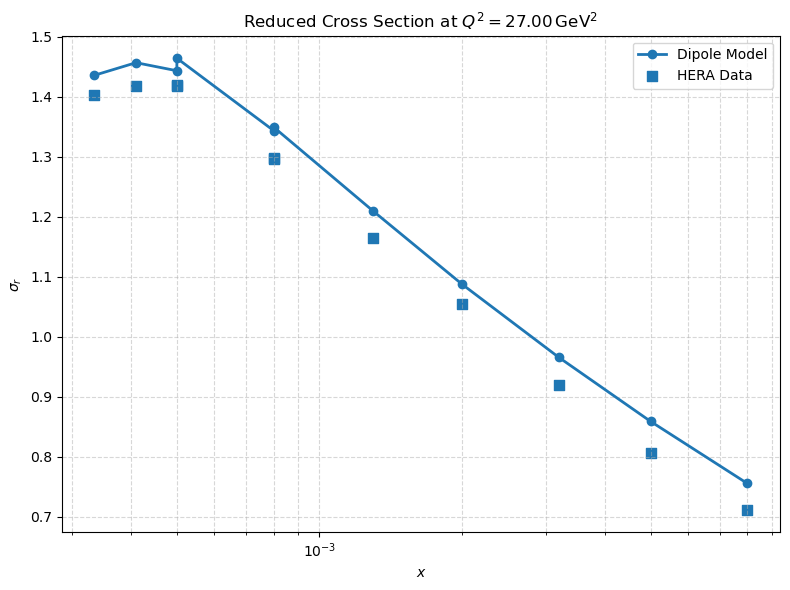

In [124]:
# ----------------------------------------------------------
# Fixed Q² Reduced Cross Section Plot
# Using physical HERA x-values only
# ----------------------------------------------------------

# Desired Q²
Q2_fixed = 27

# ----------------------------------------------------------
# Find nearest available experimental Q²
# ----------------------------------------------------------

Q2_unique = np.unique(Q2_DIS)

Q2_selected = Q2_unique[
    np.argmin(np.abs(Q2_unique - Q2_fixed))
]

print(f"Using Q² = {Q2_selected:.4f} GeV²")

# ----------------------------------------------------------
# Select only points with this Q²
# ----------------------------------------------------------

mask = Q2_DIS == Q2_selected

x_selected = x_DIS[mask]
s_selected = s_DIS[mask]

# Experimental reduced cross section
sigma_exp = sigma_r_DIS[mask]

# ----------------------------------------------------------
# Precompute Bessel functions ONCE
# ----------------------------------------------------------

z_vals, R_vals, K0_grid, K1_grid = precompute_bessel(Q2_selected)

# ----------------------------------------------------------
# Compute reduced cross section
# ----------------------------------------------------------

SigmaR_curve = np.zeros(len(x_selected))

for i in range(len(x_selected)):

    SigmaR_curve[i] = SigmaRDP(
        x_selected[i],          # x
        Q2_selected,            # fixed Q²
        s_selected[i],          # corresponding s
        z_vals,
        R_vals,
        K0_grid,
        K1_grid,
        x_vals,
        R_vals_dip,
        N_grid
    )

# ----------------------------------------------------------
# Sort for plotting
# ----------------------------------------------------------

sort_idx = np.argsort(x_selected)

x_plot = x_selected[sort_idx]
sigma_plot = SigmaR_curve[sort_idx]
sigma_exp_plot = sigma_exp[sort_idx]

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

plt.figure(figsize=(8,6))

# Theory curve
plt.plot(
    x_plot,
    sigma_plot,
    marker='o',
    linestyle='-',
    linewidth=2,
    label='Dipole Model'
)

# Experimental points
plt.scatter(
    x_plot,
    sigma_exp_plot,
    marker='s',
    s=60,
    label='HERA Data'
)

# Log x-axis
plt.xscale('log')

# Labels
plt.xlabel(r'$x$')
plt.ylabel(r'$\sigma_r$')

# Title
plt.title(
    rf'Reduced Cross Section at $Q^2={Q2_selected:.2f}\,\mathrm{{GeV}}^2$'
)

# Grid and legend
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

In [125]:
print(rel_err_sigma_r_DIS[:10])

[9.76747153 8.0017748  8.72849357 7.39055478 5.49435165 6.87203754
 7.83325603 4.77138345 3.63517537 5.47506164]


In [126]:
theory = SigmaRDP_points
data   = sigma_r_DIS

abs_err = data * rel_err_sigma_r_DIS / 100

chi2_points = ((theory - data)/abs_err)**2

chi2_total = np.sum(chi2_points)

print("N points =", len(data))
print("chi2 =", chi2_total)
print("chi2/N =", chi2_total/len(data))

N points = 271
chi2 = 1287.114763074229
chi2/N = 4.749500970753612


In [127]:
sigma_err = sigma_r_DIS * rel_err_sigma_r_DIS / 100

# find largest χ² contribution
chi2_contrib = (
    (SigmaRDP_points - sigma_r_DIS)**2
    / sigma_err**2
)

largest = np.argmax(chi2_contrib)

print("largest point =", largest)
print("x =", x_DIS[largest])
print("Q² =", Q2_DIS[largest])
print("theory =", SigmaRDP_points[largest])
print("data =", sigma_r_DIS[largest])
print("error =", sigma_err[largest])
print("chi² contribution =", chi2_contrib[largest])

largest point = 270
x = 0.008
Q² = 45.0
theory = 0.8725743717126564
data = 0.785
error = 0.008661008558476317
chi² contribution = 102.23912522905475


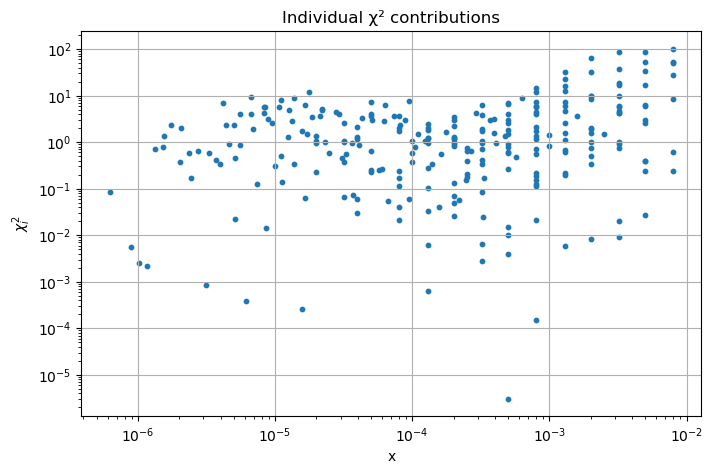

In [128]:
plt.figure(figsize=(8,5))

plt.scatter(
    x_DIS,
    chi2_contrib,
    s=10
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("x")
plt.ylabel(r"$\chi_i^2$")
plt.title("Individual χ² contributions")

plt.grid(True)
plt.show()

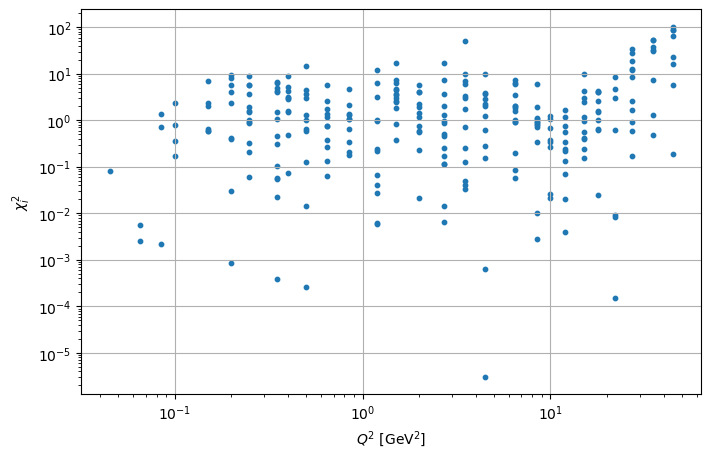

In [129]:
plt.figure(figsize=(8,5))

plt.scatter(
    Q2_DIS,
    chi2_points,
    s=10
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel(r"$Q^2$ [GeV$^2$]")
plt.ylabel(r"$\chi_i^2$")

plt.grid(True)
plt.show()

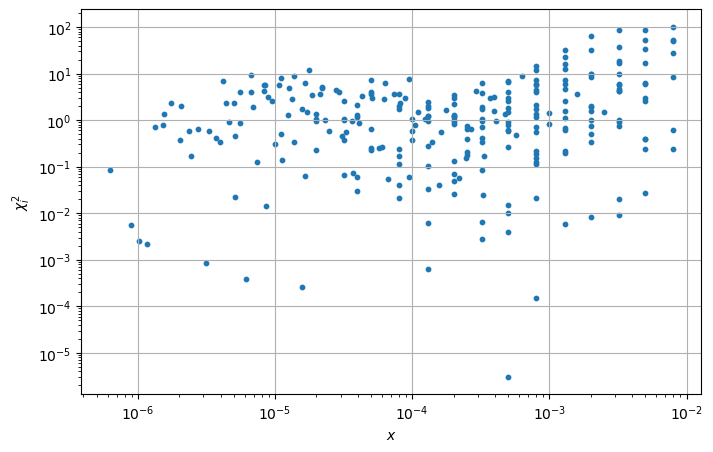

In [130]:
plt.figure(figsize=(8,5))

plt.scatter(
    x_DIS,
    chi2_points,
    s=10
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel(r"$x$")
plt.ylabel(r"$\chi_i^2$")

plt.grid(True)
plt.show()

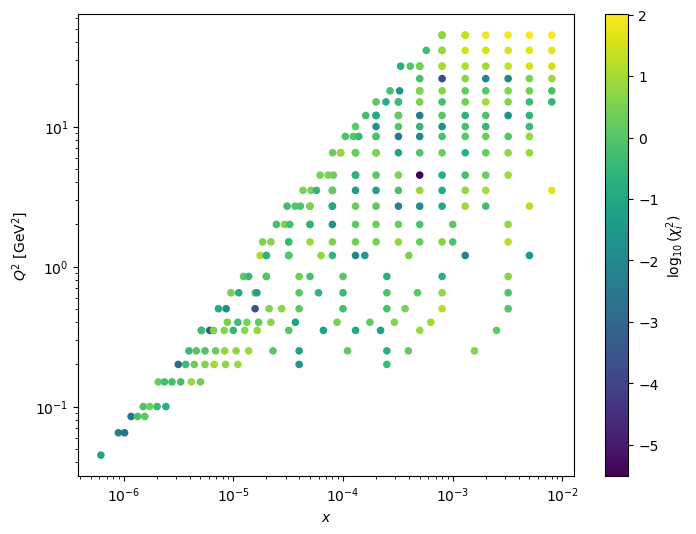

In [131]:
plt.figure(figsize=(8,6))

plt.scatter(
    x_DIS,
    Q2_DIS,
    c=np.log10(chi2_points),
    s=20
)

plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'$x$')
plt.ylabel(r'$Q^2$ [GeV$^2$]')

cbar = plt.colorbar()
cbar.set_label(r'$\log_{10}(\chi_i^2)$')

plt.show()

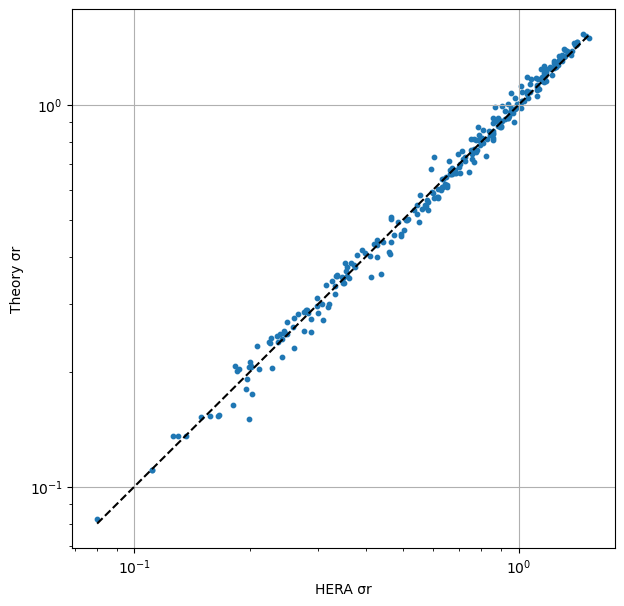

In [132]:
plt.figure(figsize=(7,7))

plt.scatter(
    sigma_r_DIS,
    SigmaRDP_points,
    s=10
)

# perfect agreement line
xmin = min(np.min(sigma_r_DIS), np.min(SigmaRDP_points))
xmax = max(np.max(sigma_r_DIS), np.max(SigmaRDP_points))

plt.plot(
    [xmin, xmax],
    [xmin, xmax],
    'k--'
)

plt.xlabel("HERA σr")
plt.ylabel("Theory σr")

plt.xscale("log")
plt.yscale("log")

plt.grid(True)
plt.show()

In [133]:
ratio = SigmaRDP_points / sigma_r_DIS
print(ratio)

[1.02811421 0.99396102 0.99560565 0.99653962 1.04684645 1.07940608
 0.93060131 0.92720415 0.97798182 1.02258577 0.89582003 1.03469494
 1.02691485 1.0230613  1.08704796 1.08617092 1.00138997 1.02203362
 1.04440189 1.05457499 1.07920809 1.07038166 1.12353356 0.9640294
 0.90258342 1.03292068 1.0385069  1.0285219  1.03895536 1.06549771
 1.06195875 1.0790738  1.0420584  1.01166819 1.06105013 0.97622127
 0.92571297 0.75592273 1.00814608 0.82558571 0.99726341 1.06473946
 1.06253114 1.01550684 1.06070349 1.06463275 1.04356546 1.00821638
 1.01084372 1.00911007 0.90296045 0.864324   1.08986411 1.02492089
 1.05521752 1.03497419 1.0630588  1.01151281 0.93704867 0.95317689
 0.92446627 0.88201269 1.03299555 0.98695776 0.9992444  1.0602912
 1.06387177 1.05022461 0.97831737 0.97686942 0.94669288 0.88393988
 1.13176937 1.09265763 0.97633932 1.08468561 0.97921808 0.95739476
 1.0262648  0.97895051 0.9723146  0.96021508 0.92711532 1.05895615
 1.04904019 0.92634696 0.9477476  0.93825137 0.95204259 0.952827

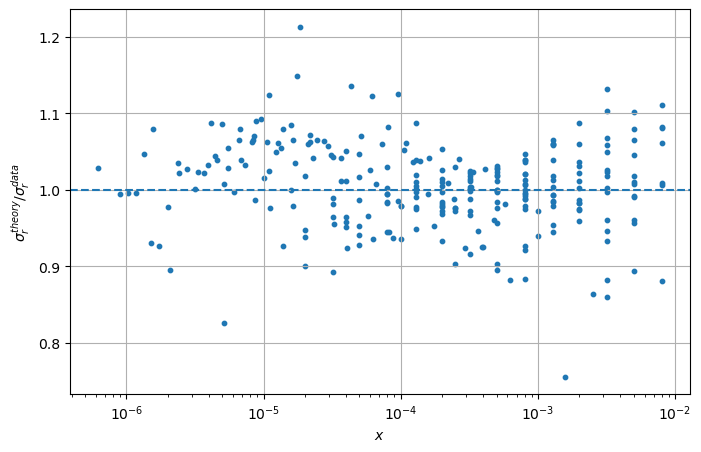

In [134]:
plt.figure(figsize=(8,5))

plt.scatter(
    x_DIS,
    ratio,
    s=10
)

plt.xscale('log')

plt.axhline(1.0, linestyle='--')

plt.xlabel(r'$x$')
plt.ylabel(r'$\sigma_r^{theory}/\sigma_r^{data}$')

plt.grid(True)
plt.show()

In [135]:
for n in [300, 500, 700, 1000]:

    z_vals, R_vals, K0_grid, K1_grid = precompute_bessel(
        8.5,
        nZ=n,
        nR=n
    )

    sigma = SigmaRDP(
        1.05e-4,
        8.5,
        319.0**2,
        z_vals,
        R_vals,
        K0_grid,
        K1_grid,
        x_vals,
        R_vals_dip,
        N_grid
    )

    print(n, sigma)

300 1.2381831695387955
500 1.243436217570905
700 1.2427340996448657
1000 1.2409547487693289


In [136]:
residual = (
    SigmaRDP_points - sigma_r_DIS
) / sigma_r_DIS

print("mean =", np.mean(residual))
print("std  =", np.std(residual))
print("max  =", np.max(residual))
print("min  =", np.min(residual))

mean = 0.004878208804920161
std  = 0.05680991489635123
max  = 0.21336858710991757
min  = -0.24407727273541868


In [137]:
for i in range(10):
    print(
        sigma_r_DIS[i],
        rel_err_sigma_r_DIS[i]
    )

0.08 9.767471525425606
0.111 8.001774803129615
0.111 8.72849356991228
0.136 7.3905547829645375
0.13 5.49435164509881
0.126 6.872037543552858
0.165 7.83325602798734
0.166 4.771383447177558
0.157 3.6351753740363066
0.149 5.475061643488592


In [138]:
abs_err = sigma_r_DIS * rel_err_sigma_r_DIS / 100.0

chi2_contrib = (
    (SigmaRDP_points - sigma_r_DIS) / abs_err
)**2

idx = np.argsort(chi2_contrib)[::-1]

for k in range(20):

    i = idx[k]

    print(
        i,
        "x =", x_DIS[i],
        "Q2 =", Q2_DIS[i],
        "data =", sigma_r_DIS[i],
        "theory =", SigmaRDP_points[i],
        "chi2 =", chi2_contrib[i]
    )

270 x = 0.008 Q2 = 45.0 data = 0.785 theory = 0.8725743717126564 chi2 = 102.23912522905476
268 x = 0.0032 Q2 = 45.0 data = 1.0170000000000001 theory = 1.1214209157468524 chi2 = 88.23438750960923
269 x = 0.005 Q2 = 45.0 data = 0.903 theory = 0.9949554964793997 chi2 = 87.60688505301873
267 x = 0.002 Q2 = 45.0 data = 1.163 theory = 1.2644435267906067 chi2 = 64.28124699330364
261 x = 0.005 Q2 = 35.0 data = 0.857 theory = 0.9254411604104921 chi2 = 51.94097354251252
262 x = 0.008 Q2 = 35.0 data = 0.7509999999999999 theory = 0.8126373311942335 chi2 = 51.887909454815826
158 x = 0.008 Q2 = 3.5 data = 0.463 theory = 0.40776371735807615 chi2 = 50.38654437417094
260 x = 0.0032 Q2 = 35.0 data = 0.976 theory = 1.042052651894668 chi2 = 37.93409347494721
253 x = 0.005 Q2 = 27.0 data = 0.8059999999999999 theory = 0.8587886568973726 chi2 = 33.32720177256616
259 x = 0.002 Q2 = 35.0 data = 1.1079999999999999 theory = 1.1747604588727043 chi2 = 31.96090041165959
258 x = 0.0013 Q2 = 35.0 data = 1.234 theory 

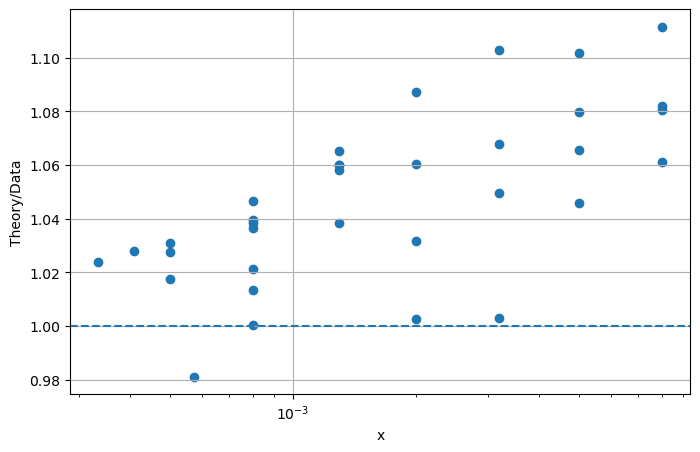

In [139]:
plt.figure(figsize=(8,5))

mask = Q2_DIS > 20

plt.scatter(
    x_DIS[mask],
    SigmaRDP_points[mask] / sigma_r_DIS[mask]
)

plt.axhline(1.0, ls='--')
plt.xscale('log')

plt.xlabel("x")
plt.ylabel("Theory/Data")

plt.grid(True)
plt.show()

In [140]:
for Q2 in np.unique(Q2_DIS):

    mask = (Q2_DIS == Q2)

    chi2_q2 = np.sum(chi2_contrib[mask])

    print(
        Q2,
        chi2_q2 / np.sum(mask)
    )

0.045 0.08284901296419964
0.065 0.004115196137907393
0.085 0.6881128673147551
0.1 0.9124092668424083
0.15 2.2098841984106232
0.2 3.352010840624443
0.25 2.4959468664892963
0.35 2.107326096169804
0.4 3.101905050629425
0.5 2.6483155089619856
0.65 1.349256382791927
0.85 1.291498334004061
1.2 2.002449770173435
1.5 4.465367706848351
2.0 1.8995533475616186
2.7 2.308164743948266
3.5 6.3371582431161295
4.5 2.229148166109702
6.5 2.4176369378444886
8.5 1.2266942243064054
10.0 0.5038915866119749
12.0 0.47381258673163895
15.0 2.1434875176475345
18.0 2.0197646373991627
22.0 2.35341742202487
27.0 10.874516515516051
35.0 26.768446708001385
45.0 48.4460595921133


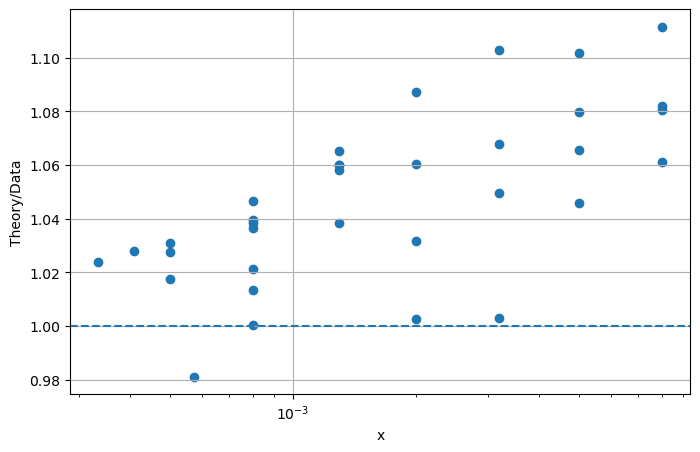

In [141]:
plt.figure(figsize=(8,5))

mask = Q2_DIS > 20

plt.scatter(
    x_DIS[mask],
    SigmaRDP_points[mask] / sigma_r_DIS[mask]
)

plt.axhline(1.0, ls='--')
plt.xscale('log')

plt.xlabel("x")
plt.ylabel("Theory/Data")

plt.grid(True)
plt.show()

In [142]:
mask1 = x_DIS < 1e-3
mask2 = x_DIS < 3e-3
mask3 = x_DIS < 1e-2

for label, mask in [
    ("x < 1e-3", mask1),
    ("x < 3e-3", mask2),
    ("x < 1e-2", mask3),
]:
    chi2 = np.sum(chi2_contrib[mask])
    N = np.sum(mask)

    print(label)
    print("N =", N)
    print("chi2/N =", chi2/N)
    print()

x < 1e-3
N = 205
chi2/N = 1.8995314740673208

x < 3e-3
N = 237
chi2/N = 2.689805382067306

x < 1e-2
N = 271
chi2/N = 4.749500970753612



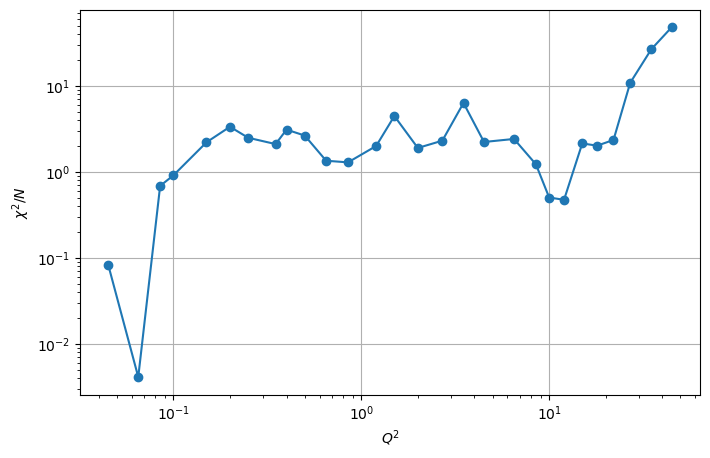

In [143]:
Q2_unique = np.unique(Q2_DIS)

chi2_q2 = []
Q2_vals = []

for q2 in Q2_unique:

    mask = (Q2_DIS == q2)

    chi2 = np.sum(chi2_contrib[mask])
    N = np.sum(mask)

    chi2_q2.append(chi2 / N)
    Q2_vals.append(q2)

plt.figure(figsize=(8,5))

plt.plot(Q2_vals, chi2_q2, marker='o')

plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'$Q^2$')
plt.ylabel(r'$\chi^2/N$')

plt.grid(True)
plt.show()

In [144]:
idx = 185

x_val  = x_DIS[idx]
Q2_val = Q2_DIS[idx]
s_val  = s_DIS[idx]

for n in [300,500,700,1000,1500]:

    z_vals, R_vals, K0_grid, K1_grid = precompute_bessel(
        Q2_val,
        nZ=n,
        nR=n
    )

    sig = SigmaRDP(
        x_val,
        Q2_val,
        s_val,
        z_vals,
        R_vals,
        K0_grid,
        K1_grid,
        x_vals,
        R_vals_dip,
        N_grid
    )

    print(n, sig)

300 1.2381831695387961
500 1.243436217570907
700 1.242734099644863
1000 1.240954748769327
1500 1.238690951839951


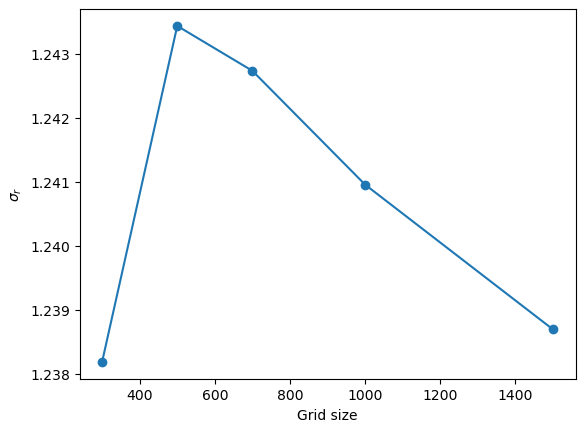

In [145]:
n_grid = np.array([300,500,700,1000,1500])
sigma  = np.array([
    1.23818317,
    1.24343622,
    1.24273410,
    1.24095475,
    1.23869095
])

plt.plot(n_grid, sigma, marker='o')
plt.xlabel("Grid size")
plt.ylabel(r"$\sigma_r$")
plt.show()